In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.metrics import r2_score

In [81]:
df = pd.read_csv('placement.csv')

X = df.drop('Salary_Offered_LPA', axis=1)
y = df['Salary_Offered_LPA']

# convert into array
X = np.array(X)
y = np.array(y)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)
y_pred = reg.predict(X_test)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")

[ 3.90215203 -0.06494533  0.03939589  0.2209365   0.16680157]
-19.798897788268015
R^2 Score: 0.9992


In [84]:
class my_linear_regression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        self.betas_ = None  # Store full beta vector
    
    def fit(self, X_train, y_train):
        # insert one into X_train
        X_train = np.insert(X_train, 0, 1, axis=1)
        
        # calculate betas
        betas = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
        
        # store parameters
        self.betas_ = betas  # Store full betas
        self.coef_ = betas[1:]  # All except first (since first is intercept)
        self.intercept_ = betas[0]  # First element is intercept

    def predict(self, X_test):
        # Method 1: Use betas directly
        X_test = np.insert(X_test, 0, 1, axis=1)
        return X_test @ self.betas_  # Matrix multiplication
        y_hat = X_test @ self.coef_ + self.intercept_  # Matrix multiplication
        
        

In [85]:
new_model_lr = my_linear_regression()
new_model_lr.fit(X_train, y_train)
y_pred_new = new_model_lr.predict(X_test)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"coefficients and intercept is {new_model_lr.betas_}")

R^2 Score: 0.9992
coefficients and intercept is [-19.79889779   3.90215203  -0.06494533   0.03939589   0.2209365
   0.16680157]


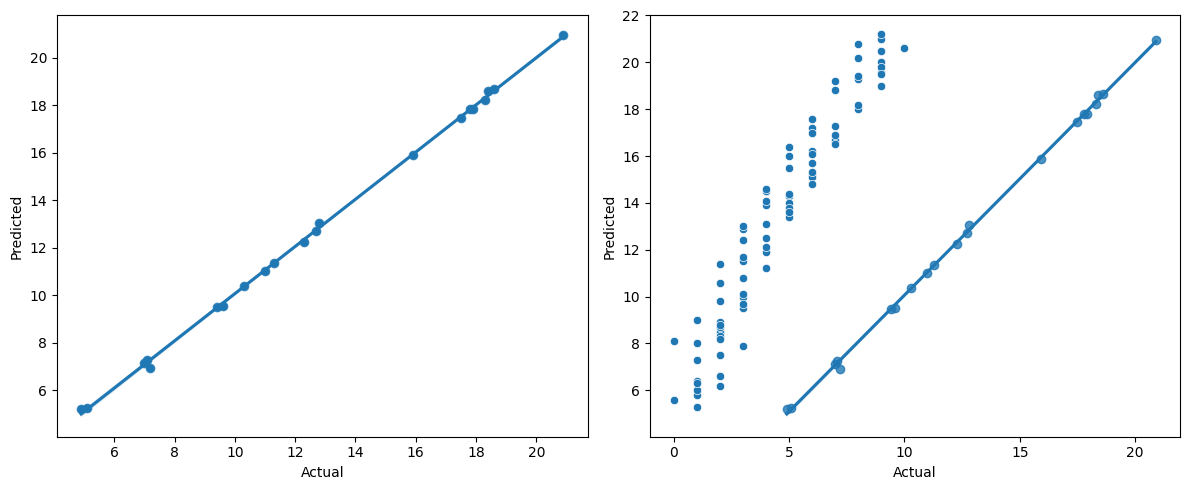

In [88]:
# sub figure
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

sns.scatterplot(x = y_test, y = y_pred)
sns.regplot(x = y_test, y = y_pred)
# labels and add legends

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()

plt.subplot(1, 2, 2)

sns.scatterplot(x = X_train[:, 1], y = y_train)
sns.regplot(x = y_test, y = y_pred_new)
# labels and add legends

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()